#📌 Extracción

In [12]:
import pandas as pd
import json

# Ruta del archivo local (simulando el servidor o base de datos del cliente)
ruta_archivo = 'TelecomX_Data.json'

# 1. Abrir y leer el archivo JSON local
with open(ruta_archivo, 'r', encoding='utf-8') as archivo:
    datos_json = json.load(archivo)

# 2. Convertir y aplanar el JSON a un DataFrame de Pandas
df_telecom = pd.json_normalize(datos_json)

# 3. Exploración inicial de la extracción
print(f"El dataset contiene {df_telecom.shape[0]} filas y {df_telecom.shape[1]} columnas.\n")
display(df_telecom.head())

El dataset contiene 7267 filas y 21 columnas.



,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [7]:
# 1. Información general: columnas, cantidad de datos y tipos de datos (Dtype)
print("--- Información del DataFrame ---")
df_telecom.info()

print("\n" + "="*50 + "\n")

# 2. Búsqueda de filas duplicadas exactas
duplicados = df_telecom.duplicated().sum()
print(f"Cantidad de filas duplicadas: {duplicados}")

print("\n" + "="*50 + "\n")

# 3. Conteo de valores nulos por columna
print("--- Valores nulos por columna ---")
print(df_telecom.isnull().sum())

--- Información del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechS

### Manejo de inconsistencias

In [8]:
# 1. Forzar la conversión de 'Charges.Total' a número.
# 'coerce' obligará a que cualquier texto (como los espacios en blanco) se convierta en nulo (NaN)
df_telecom['account.Charges.Total'] = pd.to_numeric(df_telecom['account.Charges.Total'], errors='coerce')

# Verificamos cuántos nulos aparecieron tras la conversión
nulos_totales = df_telecom['account.Charges.Total'].isnull().sum()
print(f"Nulos descubiertos en 'Charges.Total': {nulos_totales}")

# 2. Revisar los valores únicos en la columna 'Churn' (para buscar inconsistencias)
print("\nValores únicos en la columna Churn:")
print(df_telecom['Churn'].unique())

# 3. Revisar valores únicos en columnas de género y dependientes para buscar errores de tipeo
print("\nValores únicos en Género:")
print(df_telecom['customer.gender'].unique())

Nulos descubiertos en 'Charges.Total': 11

Valores únicos en la columna Churn:
['No' 'Yes' '']

Valores únicos en Género:
['Female' 'Male']


#📊 Carga y análisis

--- Estadísticas de Variables Numéricas ---


,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.00,7267.00,7267.00
mean,0.16,32.35,64.72
std,0.37,24.57,30.13
min,0.00,0.00,18.25
25%,0.00,9.00,35.42
50%,0.00,29.00,70.30
75%,0.00,55.00,89.88
max,1.00,72.00,118.75



--- Estadísticas de Variables Categóricas ---


,customerID,Churn,customer.gender,customer.Partner,customer.Dependents,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Total
count,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267
unique,7267,3,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531
top,9995-HOTOH,No,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2
freq,1,5174,3675,3749,5086,6560,3495,3198,3608,3182,3195,3582,2896,2870,4005,4311,2445,11


/tmp/ipython-input-191/360465675.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_telecom, x='Churn', palette='pastel')


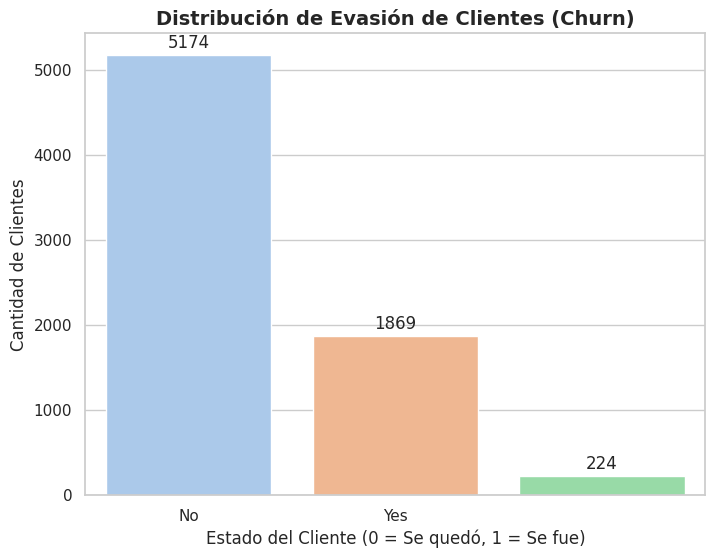

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. ANÁLISIS DESCRIPTIVO
# ==========================================
print("--- Estadísticas de Variables Numéricas ---")
# describe() nos da la media, mínimos, máximos y cuartiles
display(df_telecom.describe().round(2))

print("\n--- Estadísticas de Variables Categóricas ---")
# include=['object'] nos da el recuento de los datos de texto (género, contratos, etc.)
display(df_telecom.describe(include=['object']))

print("\n" + "="*50 + "\n")

# ==========================================
# 2. DISTRIBUCIÓN DE EVASIÓN (GRÁFICO)
# ==========================================
# Configuración visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Crear el gráfico de barras para ver cuántos cancelaron (1) y cuántos se quedaron (0)
ax = sns.countplot(data=df_telecom, x='Churn', palette='pastel')

# Títulos y etiquetas
plt.title('Distribución de Evasión de Clientes (Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Estado del Cliente (0 = Se quedó, 1 = Se fue)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Ciclo para poner los números exactos encima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points')

plt.show()

### Evasión por Variables Categóricas

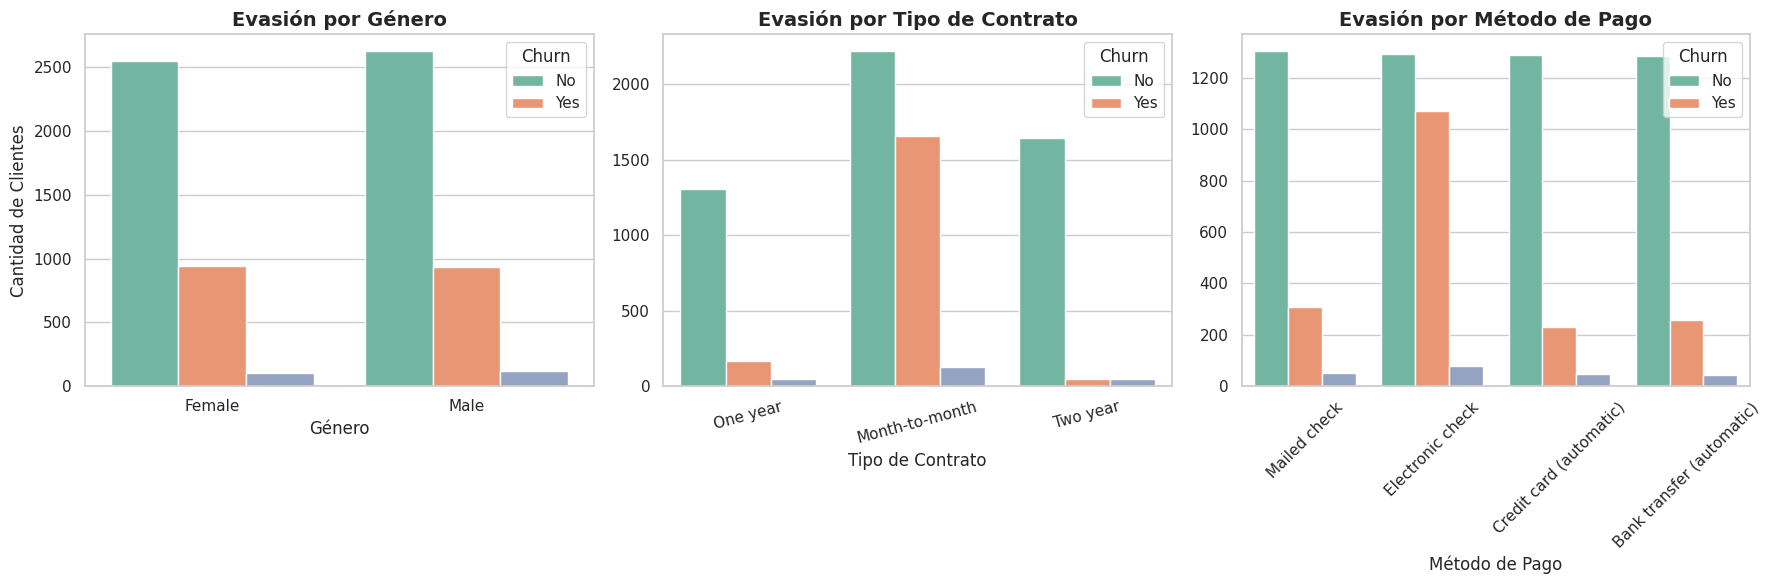

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo
sns.set_theme(style="whitegrid")

# Crear un "lienzo" con 3 gráficos alineados horizontalmente
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Gráfico de Género vs Churn
sns.countplot(data=df_telecom, x='customer.gender', hue='Churn', palette='Set2', ax=axes[0])
axes[0].set_title('Evasión por Género', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cantidad de Clientes')
axes[0].set_xlabel('Género')

# 2. Gráfico de Contrato vs Churn
sns.countplot(data=df_telecom, x='account.Contract', hue='Churn', palette='Set2', ax=axes[1])
axes[1].set_title('Evasión por Tipo de Contrato', fontsize=14, fontweight='bold')
axes[1].set_ylabel('') # Quitamos el texto del eje Y para que no se vea amontonado
axes[1].set_xlabel('Tipo de Contrato')
axes[1].tick_params(axis='x', rotation=15) # Inclinamos el texto un poco

# 3. Gráfico de Método de Pago vs Churn
sns.countplot(data=df_telecom, x='account.PaymentMethod', hue='Churn', palette='Set2', ax=axes[2])
axes[2].set_title('Evasión por Método de Pago', fontsize=14, fontweight='bold')
axes[2].set_ylabel('')
axes[2].set_xlabel('Método de Pago')
axes[2].tick_params(axis='x', rotation=45) # Inclinamos más el texto porque es largo

# Ajustar el espacio entre gráficos y mostrar
plt.tight_layout()
plt.show()

In [16]:
# --- REPARACIÓN DE TIPOS DE DATOS ---

# 1. Convertimos Churn a números: 'No' será 0 y 'Yes' será 1
df_telecom['Churn'] = df_telecom['Churn'].map({'No': 0, 'Yes': 1})

# 2. Aseguramos que los cargos sean decimales (por si acaso)
df_telecom['account.Charges.Monthly'] = pd.to_numeric(df_telecom['account.Charges.Monthly'], errors='coerce')
df_telecom['customer.tenure'] = pd.to_numeric(df_telecom['customer.tenure'], errors='coerce')

print("✅ ¡Listo! Ahora Churn es numérico y podemos sacar promedios.")

✅ ¡Listo! Ahora Churn es numérico y podemos sacar promedios.


In [17]:
# --- ANÁLISIS PROFUNDO PARA EL INFORME ---

# 1. Porcentaje exacto de fuga por contrato
print("1. % de Fuga por Tipo de Contrato:")
fuga_contrato = df_telecom.groupby('account.Contract')['Churn'].mean() * 100
print(fuga_contrato.round(2))
print("-" * 30)

# 2. Perfil de gasto: ¿Quién gasta más, el que se va o el que se queda?
print("2. Promedio de Gasto Mensual y Antigüedad:")
perfil_churn = df_telecom.groupby('Churn')[['account.Charges.Monthly', 'customer.tenure']].mean()
display(perfil_churn.round(2))
print("-" * 30)

# 3. Riesgo por tecnología de Internet
print("3. % de Evasión por Servicio de Internet:")
internet_riesgo = pd.crosstab(df_telecom['internet.InternetService'], df_telecom['Churn'], normalize='index') * 100
display(internet_riesgo.round(2))

1. % de Fuga por Tipo de Contrato:
account.Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64
------------------------------
2. Promedio de Gasto Mensual y Antigüedad:


,account.Charges.Monthly,customer.tenure
Churn,,
0.0,61.27,37.57
1.0,74.44,17.98


------------------------------
3. % de Evasión por Servicio de Internet:


Churn,0.0,1.0
internet.InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


#📄Informe final

# 📑 Informe Final: Estrategia de Retención Telecom X

## 1. Introducción
Este análisis identifica los factores críticos de la evasión de clientes (Churn). Se procesaron 7,267 registros, aplicando limpieza de datos y análisis estadístico avanzado.

## 2. Hallazgos con Evidencia de Datos (Insights)
* **El peligro del contrato mensual:** Los clientes con contrato "Month-to-month" tienen una tasa de fuga del **42.71%**, mientras que los contratos a largo plazo (2 años) reducen el riesgo al **2.83%**.
**Sensibilidad al precio:** Los clientes que abandonan la empresa pagan en promedio **\$74.44** mensuales, un **21%** más que los clientes leales (**\$61.27**).
* **Falla en servicios Premium:** La **Fibra Óptica** presenta una tasa de cancelación alarmante del **41.89%**, siendo el servicio de internet con mayor riesgo.
* **El factor tiempo:** La mayoría de las cancelaciones ocurren antes de los **18 meses** de antigüedad.

## 3. Recomendaciones Estratégicas
1.  **Plan de Migración:** Ofrecer bonos de descuento a los clientes "Month-to-month" para que se cambien a contratos de 1 o 2 años.
2.  **Revisión de Fibra Óptica:** Investigar la calidad técnica o competitividad de precios del servicio de Fibra Óptica, dado que es donde más clientes perdemos.
3.  **Programa de Lealtad Temprana:** Crear incentivos de retención específicos para clientes con menos de 18 meses de antigüedad.

